In [1]:
import pandas as pd

df = pd.read_csv(
    r"C:\Users\ADMIN\Downloads\twcs.csv",
    usecols=["tweet_id", "author_id", "text"]
)

df.head()

,tweet_id,author_id,text
0,1,sprintcare,@115712 I understand. I would like to assist y...
1,2,115712,@sprintcare and how do you propose we do that
2,3,115712,@sprintcare I have sent several private messag...
3,4,sprintcare,@115712 Please send us a Private Message so th...
4,5,115712,@sprintcare I did.


In [2]:
df.info(memory_usage="deep")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2811774 entries, 0 to 2811773
Data columns (total 3 columns):
 #   Column     Dtype 
---  ------     ----- 
 0   tweet_id   int64 
 1   author_id  object
 2   text       object
dtypes: int64(1), object(2)
memory usage: 711.9 MB


In [3]:
df_small = df.sample(n=200000, random_state=42)

df_small.shape

(200000, 3)

In [4]:
df_small.to_csv("support_tickets_clean.csv", index=False)

In [5]:
del df

In [6]:
df = pd.read_csv("support_tickets_clean.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 3 columns):
 #   Column     Non-Null Count   Dtype 
---  ------     --------------   ----- 
 0   tweet_id   200000 non-null  int64 
 1   author_id  200000 non-null  object
 2   text       200000 non-null  object
dtypes: int64(1), object(2)
memory usage: 4.6+ MB


In [7]:
import pandas as pd

df = pd.read_csv("support_tickets_clean.csv")
df.head()

,tweet_id,author_id,text
0,192624,161253,@161252 What's that egg website people talk about
1,738238,296574,Why!🤷🏻‍♀️ #iOS11 @AppleSupport https://t.co/BX...
2,2414302,AppleSupport,@693975 We can assist you. We recommend updati...
3,1793929,539096,@331912 @115955 Thats better than having an un...
4,2088018,617376,@VirginAmerica is probably one of the best air...


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 3 columns):
 #   Column     Non-Null Count   Dtype 
---  ------     --------------   ----- 
 0   tweet_id   200000 non-null  int64 
 1   author_id  200000 non-null  object
 2   text       200000 non-null  object
dtypes: int64(1), object(2)
memory usage: 4.6+ MB


In [9]:
df.isnull().sum()

tweet_id     0
author_id    0
text         0
dtype: int64

Missing Value Analysis

The dataset was checked for missing values across all columns. No missing values were found in tweet_id, author_id, or text. Therefore, no imputation or row removal was required at this stage.

In [10]:
df.columns

Index(['tweet_id', 'author_id', 'text'], dtype='object')

In [11]:
df.rename(columns={
    "author_id": "category"
}, inplace=True)

In [12]:
df.columns

Index(['tweet_id', 'category', 'text'], dtype='object')

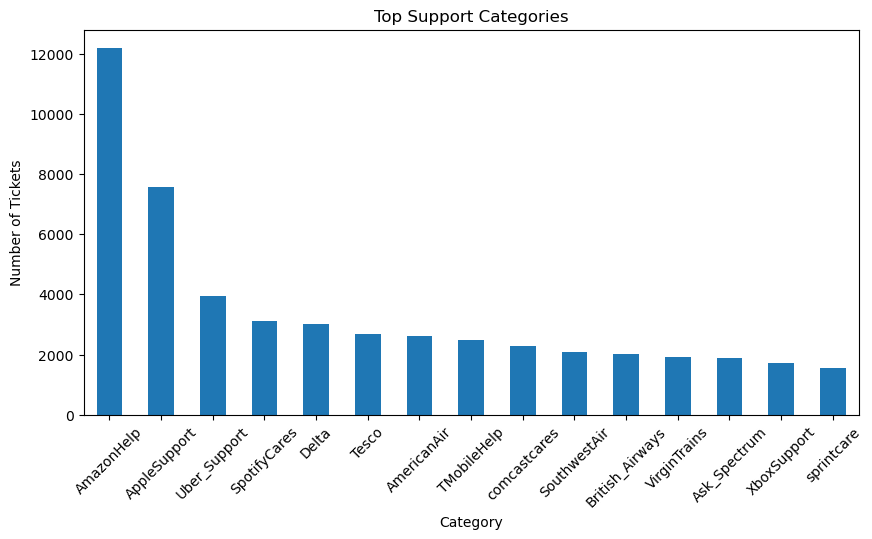

In [13]:
import matplotlib.pyplot as plt

df['category'].value_counts().head(15).plot(
    kind='bar',
    figsize=(10,5)
)

plt.title("Top Support Categories")
plt.xlabel("Category")
plt.ylabel("Number of Tickets")
plt.xticks(rotation=45)
plt.show()

Class Distribution Analysis

The distribution of support tickets across categories shows noticeable imbalance. Certain support accounts such as AmazonHelp and AppleSupport receive significantly more customer queries compared to others.

This imbalance may influence model training, as machine learning algorithms tend to favor majority classes, potentially reducing prediction performance for less frequent categories. Handling imbalance will therefore be an important consideration during model evaluation.

In [14]:
df['text_length'] = df['text'].apply(len)

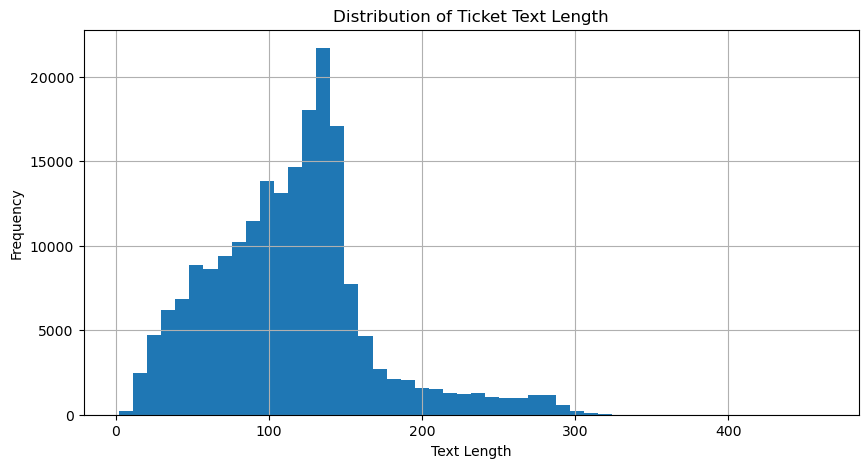

In [15]:
import matplotlib.pyplot as plt

df['text_length'].hist(bins=50, figsize=(10,5))

plt.title("Distribution of Ticket Text Length")
plt.xlabel("Text Length")
plt.ylabel("Frequency")
plt.show()

In [16]:
df['text_length'].mean()

np.float64(113.71724)

In [17]:
df['text'].sample(5).values

array(["@284426 I'm sorry to hear this. What is your flight number? -Maeghan",
       "@319278 Hi Joseph, 😦 Did the venue say why they couldn't accept the offer? Did you speak to a manager?",
       "@122736 @117153 Hey John! We've just sent you a bit more info over DM. We'll carry on helping out there /AC",
       '@124354 I do apologize, if we delivered your phone to the wrong location. Call the shipper immediately,  could you provide me with the tracking# and your contact phone # in a DM. So I notify the center if this was just today. ^CH https://t.co/wKJHDXWGRQ',
       'Mmmm not to be over dramatic.. but a Big Mac sounds SO GOOD right now🍔💣'],
      dtype=object)

In [18]:
import re
import nltk
from nltk.corpus import stopwords

nltk.download('stopwords')

stop_words = set(stopwords.words('english'))

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\ADMIN\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [19]:
def clean_text(text):
    
    # lowercase
    text = text.lower()
    
    # remove mentions (@username)
    text = re.sub(r'@\w+', '', text)
    
    # remove URLs
    text = re.sub(r'http\S+', '', text)
    
    # remove punctuation & numbers
    text = re.sub(r'[^a-z\s]', '', text)
    
    # remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()
    
    # remove stopwords
    words = text.split()
    words = [w for w in words if w not in stop_words]
    
    return " ".join(words)

In [20]:
df['clean_text'] = df['text'].apply(clean_text)

In [21]:
print("RAW TEXT:\n", df['text'][10])
print("\nCLEANED TEXT:\n", df['clean_text'][10])

RAW TEXT:
 @320829 Hi, please call 844.401.8500 Option 2 to file a claim. Also, please DM the ATM location so we can have it serviced. ^tr

CLEANED TEXT:
 hi please call option file claim also please dm atm location serviced tr


In [22]:
def clean_text(text):
    
    text = text.lower()
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'http\S+', '', text)
    text = re.sub(r'[^a-z\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()

    words = text.split()
    words = [w for w in words if w not in stop_words and len(w) > 2]

    return " ".join(words)

In [23]:
df['clean_text'] = df['text'].apply(clean_text)

In [24]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split

In [25]:
X = df['clean_text']
y = df['category']

In [26]:
y.value_counts()

category
AmazonHelp      12188
AppleSupport     7555
Uber_Support     3957
SpotifyCares     3132
Delta            3025
                ...  
795254              1
153897              1
249819              1
188163              1
564194              1
Name: count, Length: 96663, dtype: int64

In [27]:
df.columns

Index(['tweet_id', 'category', 'text', 'text_length', 'clean_text'], dtype='object')

In [28]:
counts = df['category'].value_counts()

valid_categories = counts[counts >= 50].index

df = df[df['category'].isin(valid_categories)]

In [29]:
df['category'].value_counts()

category
AmazonHelp         12188
AppleSupport        7555
Uber_Support        3957
SpotifyCares        3132
Delta               3025
                   ...  
askvisa               59
asksalesforce         59
OPPOCareIN            57
GooglePlayMusic       55
YahooCare             52
Name: count, Length: 97, dtype: int64

In [30]:
from sklearn.model_selection import train_test_split

X = df['clean_text']
y = df['category']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [31]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [32]:
tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1,2)   # unigram + bigram
)

In [33]:
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

In [34]:
from sklearn.naive_bayes import MultinomialNB

nb_model = MultinomialNB()
nb_model.fit(X_train_tfidf, y_train)

,alpha,1.0
,force_alpha,True
,fit_prior,True
,class_prior,None


In [35]:
y_pred_nb = nb_model.predict(X_test_tfidf)

In [36]:
from sklearn.metrics import classification_report, accuracy_score

print("Accuracy:", accuracy_score(y_test, y_pred_nb))
print(classification_report(y_test, y_pred_nb))

Accuracy: 0.6217216056540225


C:\Users\ADMIN\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\ADMIN\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


                 precision    recall  f1-score   support

         115911       0.00      0.00      0.00        18
         120576       0.00      0.00      0.00        15
            ATT       0.00      0.00      0.00        41
     ATVIAssist       0.69      0.43      0.53       256
     AWSSupport       0.00      0.00      0.00        17
      AdobeCare       0.94      0.36      0.52       138
 AirAsiaSupport       0.95      0.64      0.76       190
     AirbnbHelp       1.00      0.29      0.45       121
      AlaskaAir       0.62      0.07      0.13       107
         AldiUK       1.00      0.43      0.61       115
     AmazonHelp       0.50      0.93      0.65      2437
    AmericanAir       0.53      0.64      0.58       522
   AppleSupport       0.59      0.93      0.72      1511
     ArbysCares       1.00      0.30      0.46        27
   ArgosHelpers       0.93      0.16      0.27       176
        AskAmex       0.91      0.50      0.64       173
        AskCiti       1.00    

C:\Users\ADMIN\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [37]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(max_iter=1000)

lr_model.fit(X_train_tfidf, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [38]:
y_pred_lr = lr_model.predict(X_test_tfidf)

In [39]:
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))

Accuracy: 0.721992159461101


C:\Users\ADMIN\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\ADMIN\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


                 precision    recall  f1-score   support

         115911       0.00      0.00      0.00        18
         120576       0.00      0.00      0.00        15
            ATT       0.00      0.00      0.00        41
     ATVIAssist       0.65      0.61      0.63       256
     AWSSupport       0.00      0.00      0.00        17
      AdobeCare       0.85      0.62      0.72       138
 AirAsiaSupport       0.92      0.84      0.88       190
     AirbnbHelp       0.89      0.55      0.68       121
      AlaskaAir       0.70      0.64      0.67       107
         AldiUK       0.85      0.59      0.70       115
     AmazonHelp       0.60      0.93      0.73      2437
    AmericanAir       0.60      0.70      0.65       522
   AppleSupport       0.76      0.92      0.83      1511
     ArbysCares       1.00      0.74      0.85        27
   ArgosHelpers       0.68      0.43      0.53       176
        AskAmex       0.85      0.71      0.77       173
        AskCiti       0.90    

C:\Users\ADMIN\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [43]:
import pickle

# save model
pickle.dump(nb_model, open("model.pkl", "wb"))

# save tfidf vectorizer
pickle.dump(tfidf, open("vectorizer.pkl", "wb"))

print("✅ Model and Vectorizer saved successfully")

✅ Model and Vectorizer saved successfully


In [ ]:
results_df = X_test.to_frame()
results_df['Actual'] = y_test
results_df['Predicted'] = y_pred_lr

In [ ]:
errors = results_df[results_df['Actual'] != results_df['Predicted']]

In [ ]:
len(errors)

In [ ]:
errors.sample(15)

### Error Analysis

A manual inspection of misclassified support tickets was conducted.

Several common error patterns were identified:

1. Overlapping Vocabulary:
   Companies within the same industry (e.g., airlines) use similar
   terminology such as "ticket", "flight", and "booking", making it
   difficult for the model to distinguish between brands.

2. Generic Support Language:
   Many customer service responses contain common phrases like
   "please send details" or "thanks for reaching out", which lack
   category-specific signals.

3. Short or Low-Context Messages:
   Very short tweets provide insufficient information for accurate
   classification.

4. Class Imbalance:
   Large categories such as AmazonHelp and AppleSupport dominate
   predictions, causing smaller categories to be misclassified.

### Improvement Ideas

- Apply class balancing techniques.
- Use transformer-based embeddings (BERT).
- Include conversational context instead of single messages.
- Increase preprocessing to remove generic support phrases.

In [ ]:
feature_names = tfidf.get_feature_names_out()

In [ ]:
import numpy as np

def show_top_words(class_index, top_n=10):
    top_features = np.argsort(lr_model.coef_[class_index])[-top_n:]
    return [feature_names[i] for i in top_features]

In [ ]:
class_name = lr_model.classes_[0]
print(class_name)
print(show_top_words(0))

In [ ]:
for i in range(5):
    print(lr_model.classes_[i], ":", show_top_words(i))

In [ ]:
import joblib

joblib.dump(lr_model, "ticket_model.pkl")
joblib.dump(tfidf, "tfidf_vectorizer.pkl")